### Importing libraries and reading dataset

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

In [2]:
data_path = 'dataset/'
categories = os.listdir(data_path)
labels = [i for i in range(len(categories))]
label_dict = dict(zip(categories, labels))  
print(label_dict)
print(categories)
print(labels)

{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']
[0, 1, 2, 3, 4]


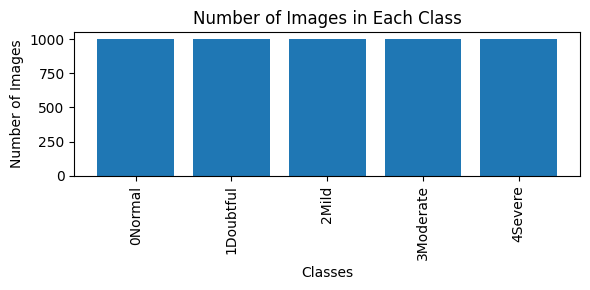

In [3]:
class_counts = {}

for category in categories:
    class_path = os.path.join(data_path, category)
    num_images = len(os.listdir(class_path))
    class_counts[category] = num_images

plt.figure(figsize=(6, 3)) 
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Number of Images in Each Class')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=90) 
plt.tight_layout() 
plt.show()

### Resizing and converting images into greyscale

In [4]:
img_size = 224
categories = ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']
label_dict = {cat: i for i, cat in enumerate(categories)}

data = []
labels = []

# Function to load and preprocess images
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Image not found")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    return img / 255.0 

data_path = "dataset/"

for category in tqdm(categories, desc="Processing categories"):
    folder_path = os.path.join(data_path, category)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            image = preprocess_image(img_path)
            data.append(image)
            labels.append(label_dict[category])
        except Exception as e:
            print(f"Error processing {img_name}: {e}")

data = np.array(data)
labels = np.array(labels)
labels = to_categorical(labels, num_classes=len(categories))

Processing categories: 100%|██████████| 5/5 [00:06<00:00,  1.31s/it]


### Splitting dataset into testing and training

In [5]:
# Split data
x_train, x_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

### CNN for Feature extraction

In [6]:
# Load VGG16 without the top classification layers
vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))

for layer in vgg_base.layers:
    layer.trainable = False

feature_extractor = Model(inputs=vgg_base.input, outputs=vgg_base.output)

x_train_features = feature_extractor.predict(x_train, batch_size=32, verbose=1)
x_val_features = feature_extractor.predict(x_val, batch_size=32, verbose=1)
x_test_features = feature_extractor.predict(x_test, batch_size=32, verbose=1)

# Reshape features for LSTM
x_train_features = x_train_features.reshape(x_train_features.shape[0], 7, -1)
x_val_features = x_val_features.reshape(x_val_features.shape[0], 7, -1)
x_test_features = x_test_features.reshape(x_test_features.shape[0], 7, -1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step


### LSTM for Classification

In [7]:
classifier_model = Sequential()

# LSTM layers for sequence processing
classifier_model.add(LSTM(256, return_sequences=True, input_shape=(7, 3584)))
classifier_model.add(Dropout(0.5))

classifier_model.add(LSTM(128, return_sequences=True))
classifier_model.add(Dropout(0.3))
classifier_model.add(BatchNormalization())

classifier_model.add(LSTM(64, return_sequences=False))
classifier_model.add(Dropout(0.2))

classifier_model.add(Dense(32, activation='relu'))
classifier_model.add(Dropout(0.2))
classifier_model.add(Dense(len(categories), activation='softmax'))

classifier_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

c:\Users\dgoya\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Model Training

In [9]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
checkpoint = ModelCheckpoint("best_model_vgg_lstm.keras", monitor='val_loss', save_best_only=True)

history = classifier_model.fit(
    x_train_features, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(x_val_features, y_val),
    callbacks=[lr_scheduler, checkpoint]
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5683 - loss: 1.0213 - val_accuracy: 0.7740 - val_loss: 0.5906 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7829 - loss: 0.5335 - val_accuracy: 0.7900 - val_loss: 0.4845 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7853 - loss: 0.5095 - val_accuracy: 0.8300 - val_loss: 0.3864 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8322 - loss: 0.4200 - val_accuracy: 0.7840 - val_loss: 0.4797 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8220 - loss: 0.4010 - val_accuracy: 0.8600 - val_loss: 0.3474 - learning_rate: 0.0010
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8513 - loss: 0.3802 - val_accuracy: 0.8520 - val_loss: 0.3583 - learning_rate: 0.0010
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8410 - 

### Evaluation

In [10]:
train_loss, train_acc = classifier_model.evaluate(x_train_features, y_train)
test_loss, test_acc = classifier_model.evaluate(x_test_features, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9786 - loss: 0.0573
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9174 - loss: 0.3392
Training Accuracy: 0.9790
Test Accuracy: 0.9180


In [11]:
y_pred = classifier_model.predict(x_test_features)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Precision: 0.9199
Recall: 0.9180
F1 Score: 0.9183


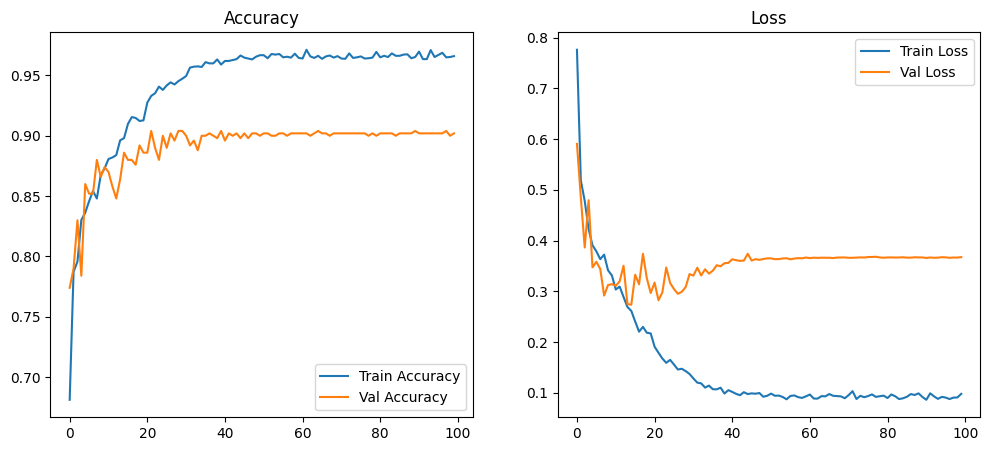

In [12]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [13]:
classifier_model.save("cnn_lstm_model.keras")

In [14]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential, Model
import cv2
import numpy as np

loaded_model = load_model("cnn_lstm_model.keras")

img_size=224
categories = ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']

# Load VGG16 without the top classification layers
vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))

for layer in vgg_base.layers:
    layer.trainable = False

feature_extractor = Model(inputs=vgg_base.input, outputs=vgg_base.output)

# Function to load and preprocess images
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Image not found")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    return img / 255.0 


def predict_single_image(image_path):
    img = preprocess_image(image_path)
    img = np.expand_dims(img, axis=0)

    # Extract features using VGG16
    img_features = feature_extractor.predict(img, verbose=0)
    img_features = img_features.reshape(1, 7, -1)

    # Make a prediction
    prediction = loaded_model.predict(img_features)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    # Get class label
    class_label = categories[predicted_class]

    return class_label, confidence

image_path = "severe_img.png"
class_label, confidence = predict_single_image(image_path)

print(f"Predicted Class: {class_label} (Confidence: {confidence:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
Predicted Class: 4Severe (Confidence: 0.9993)
